In [45]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
conn = sqlite3.connect('inventory.db')

df = pd.read_sql('select * from vendor_scorecard_final',conn)
df.head()

,VendorNumber,VendorName,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,...,total_spend,unit_cost_incl_freight,avg_payment_days,margin_percent,risk_score,risk_band,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,90026,SILVER MOUNTAIN CIDERS,4.5400,11.3900,730.00,17,77.18,52.0,381.48,7.3362,...,77.54,4.5612,30.50,0.00,0.987,HIGH,304.30,79.768271,3.058824,4.942731
1,90033,FANTASY FINE WINES CORP,5.3600,7.9900,750.00,24,128.64,41.0,327.59,7.9900,...,129.25,5.3854,29.00,32.92,0.974,HIGH,198.95,60.731402,1.708333,2.546564
2,2396,BLACK PRINCE DISTILLERY INC,7.4547,7.3900,1275.00,807,5971.94,1115.0,11818.85,10.5999,...,6002.92,7.4386,33.34,36.15,0.859,HIGH,5846.91,49.471057,1.381660,1.979064
3,90052,HAUNTING WHISPER VYDS,8.0698,11.9900,750.00,669,5388.58,611.0,7325.89,11.9900,...,5416.19,8.0959,33.10,32.70,0.854,HIGH,1937.31,26.444705,0.913303,1.359521
4,90017,THE IMPORTED GRAPE LLC,7.2305,18.6775,743.75,2280,16093.77,1736.0,22179.74,12.7763,...,16173.80,7.0938,34.40,43.90,0.836,HIGH,6085.97,27.439321,0.761404,1.378157


In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
df.isnull().sum()

VendorNumber              0
VendorName                0
PurchasePrice             0
ActualPrice               0
Volume                    0
TotalPurchaseQuantity     0
TotalPurchaseDollars      0
TotalSalesQuantity        0
TotalSalesDollars         0
TotalSalesPrice           0
TotalExciseTax            0
FreightCost               0
total_Quantity            0
total_spend               0
unit_cost_incl_freight    0
avg_payment_days          0
margin_percent            0
risk_score                0
risk_band                 0
GrossProfit               0
ProfitMargin              0
StockTurnover             0
SalestoPurchaseRatio      0
dtype: int64

In [5]:
df.describe().T

c:\Users\Asus\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
VendorNumber,129.0,2.337027e+04,3.975154e+04,2.0000,2555.000000,7153.000000,1.156700e+04,2.013590e+05
PurchasePrice,129.0,1.469027e+01,1.279596e+01,4.5400,8.510100,11.776900,1.609710e+01,1.050700e+02
ActualPrice,129.0,3.261944e+01,5.137160e+01,0.0000,14.016300,19.990000,2.999000e+01,4.706775e+02
Volume,129.0,8.625871e+02,5.901498e+02,0.0000,734.600000,753.330000,8.398400e+02,6.350000e+03
TotalPurchaseQuantity,129.0,2.853020e+05,7.119085e+05,1.0000,1847.000000,12798.000000,1.926420e+05,5.459788e+06
TotalPurchaseDollars,129.0,2.749691e+06,6.871616e+06,17.0000,25961.040000,146839.550000,1.882833e+06,5.095980e+07
TotalSalesQuantity,129.0,2.795854e+05,7.008918e+05,0.0000,1488.000000,12430.000000,1.907790e+05,5.422703e+06
TotalSalesDollars,129.0,3.881625e+06,9.568160e+06,0.0000,35508.520000,190134.630000,2.646326e+06,6.874242e+07
TotalSalesPrice,129.0,1.749359e+01,1.172774e+01,0.0000,11.511300,15.017000,1.980980e+01,1.112687e+02
TotalExciseTax,129.0,1.534896e+05,4.582217e+05,0.0000,417.020000,5327.700000,5.115563e+04,3.798655e+06


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   VendorNumber            129 non-null    int64  
 1   VendorName              129 non-null    object 
 2   PurchasePrice           129 non-null    float64
 3   ActualPrice             129 non-null    float64
 4   Volume                  129 non-null    float64
 5   TotalPurchaseQuantity   129 non-null    int64  
 6   TotalPurchaseDollars    129 non-null    float64
 7   TotalSalesQuantity      129 non-null    float64
 8   TotalSalesDollars       129 non-null    float64
 9   TotalSalesPrice         129 non-null    float64
 10  TotalExciseTax          129 non-null    float64
 11  FreightCost             129 non-null    float64
 12  total_Quantity          129 non-null    int64  
 13  total_spend             129 non-null    float64
 14  unit_cost_incl_freight  129 non-null    fl

In [7]:
df.duplicated().sum()

np.int64(0)

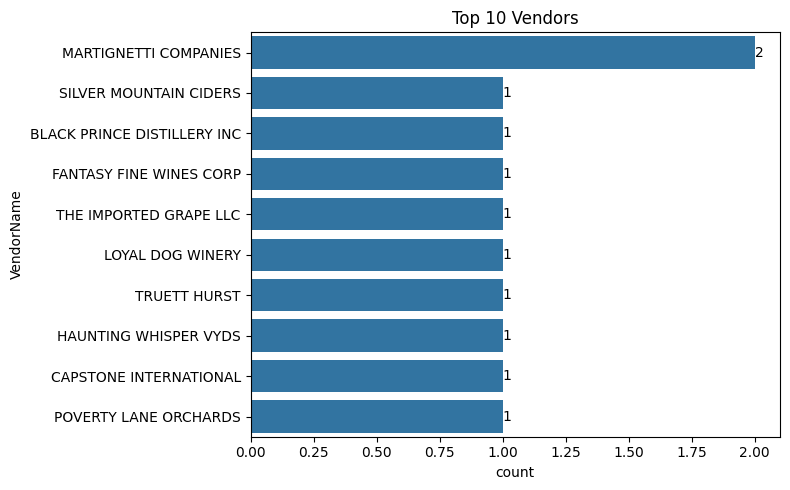

In [8]:
plt.figure(figsize=(8,5))

top_vendors = df['VendorName'].value_counts().index[:10]

ax = sns.countplot(data=df, y='VendorName', order=top_vendors)

# bar er pashe count value show
for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Vendors")
plt.tight_layout()
plt.show()

* Check Outlier

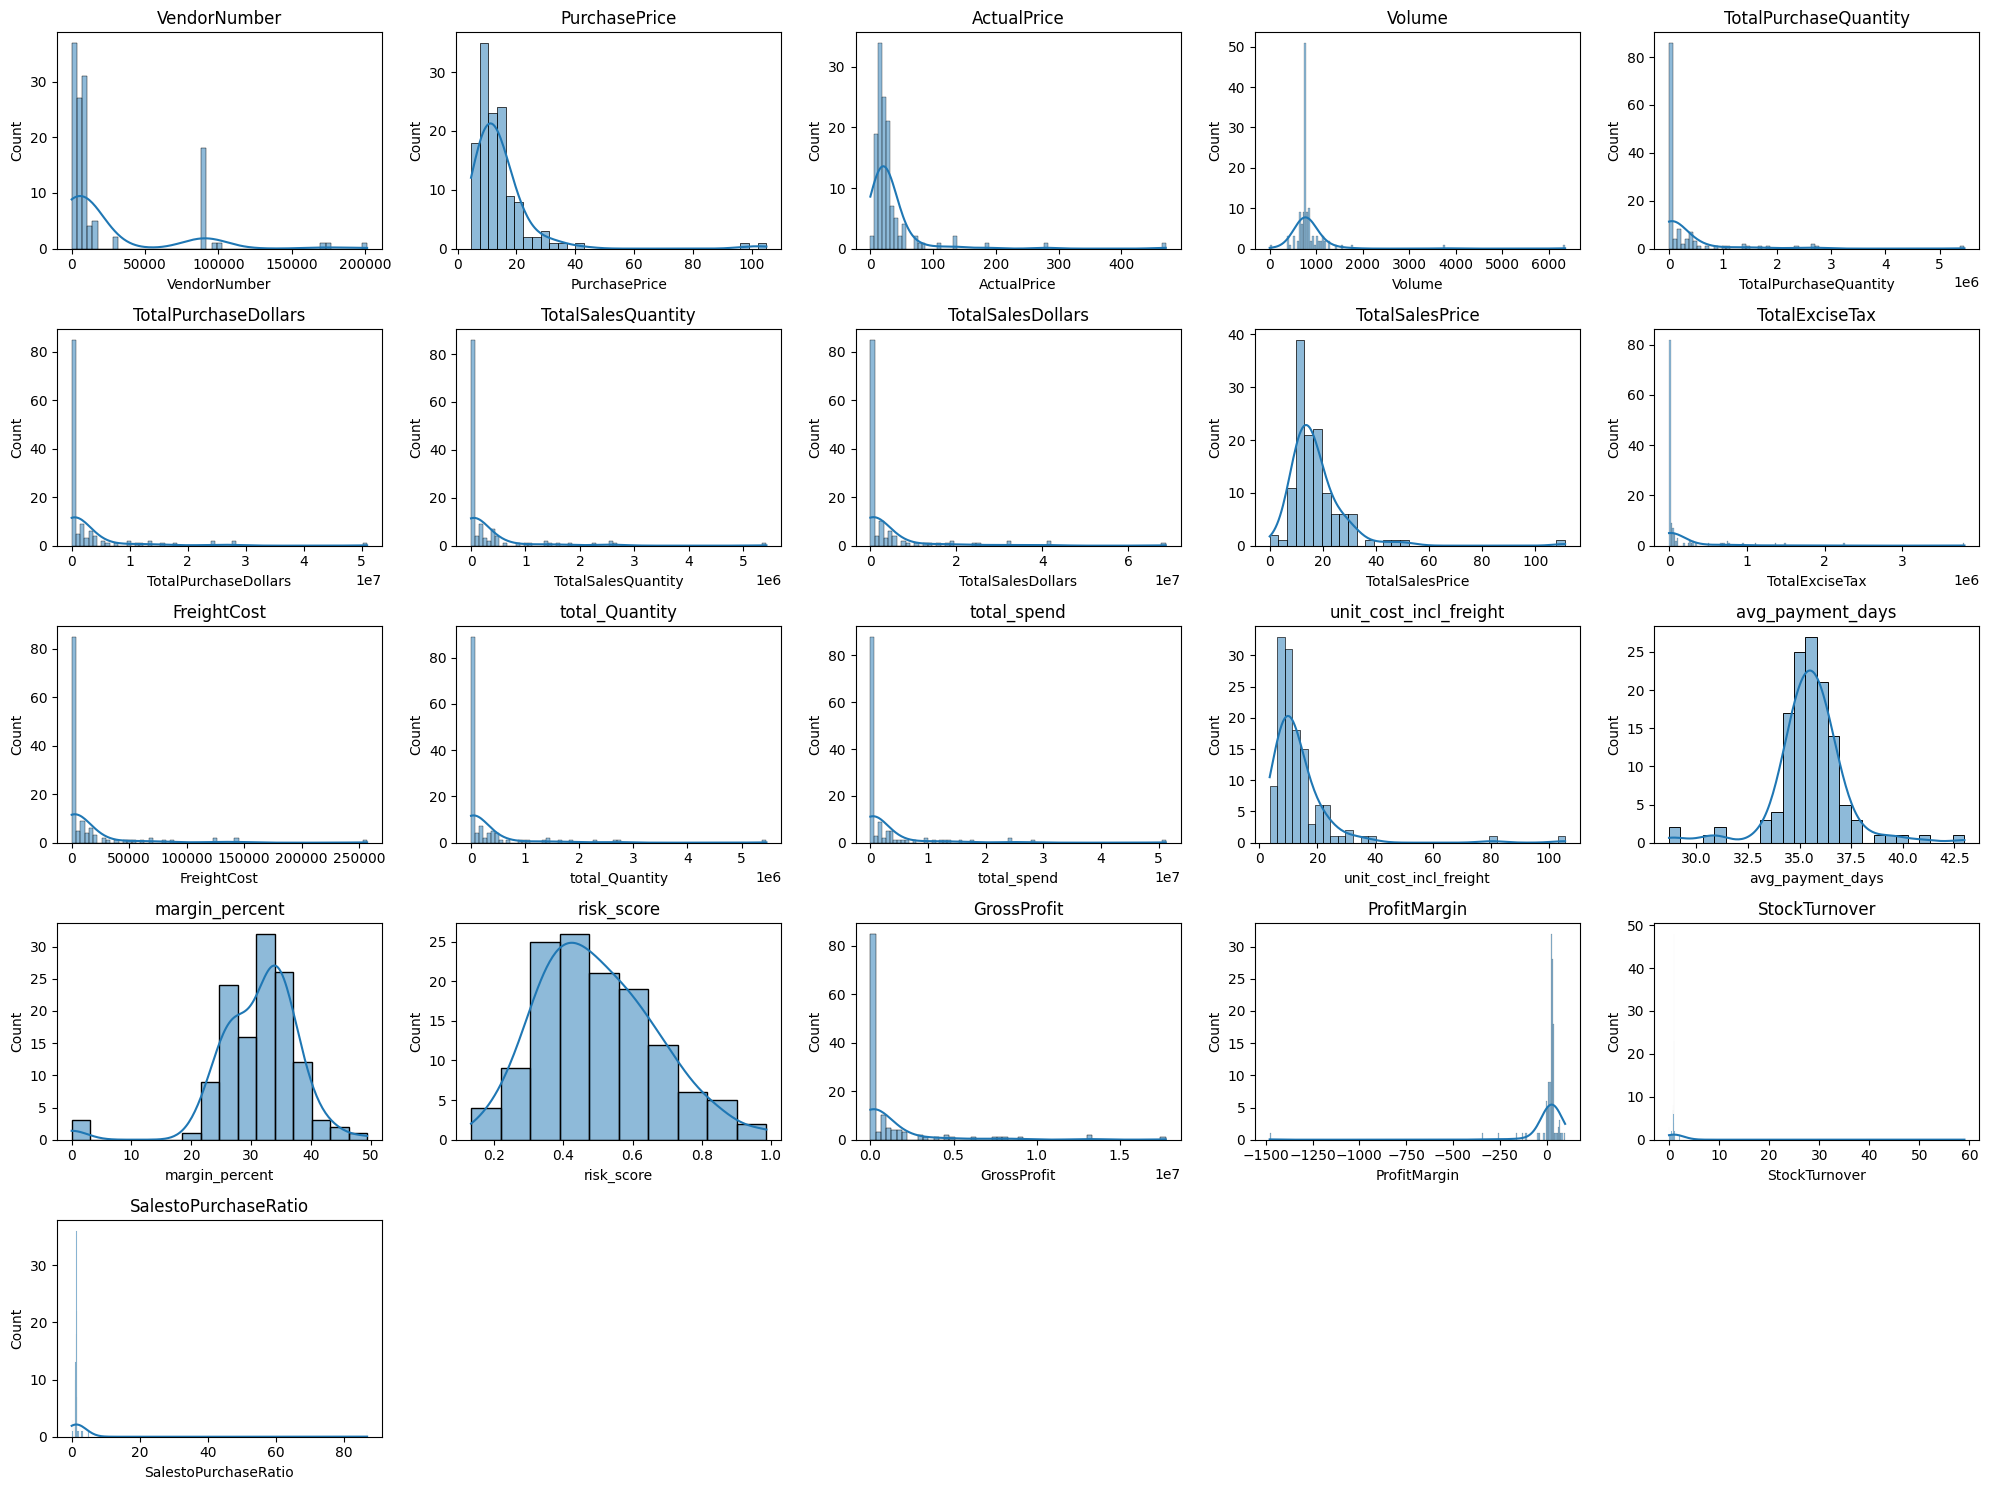

In [9]:
numeric_cols = df.select_dtypes(include=np.number)
numeric_cols = numeric_cols.replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(20,15))

for i, col in enumerate(numeric_cols.columns, 1):
    plt.subplot(5,5,i)
    sns.histplot(numeric_cols[col].dropna(), kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

* Corelation Analysis

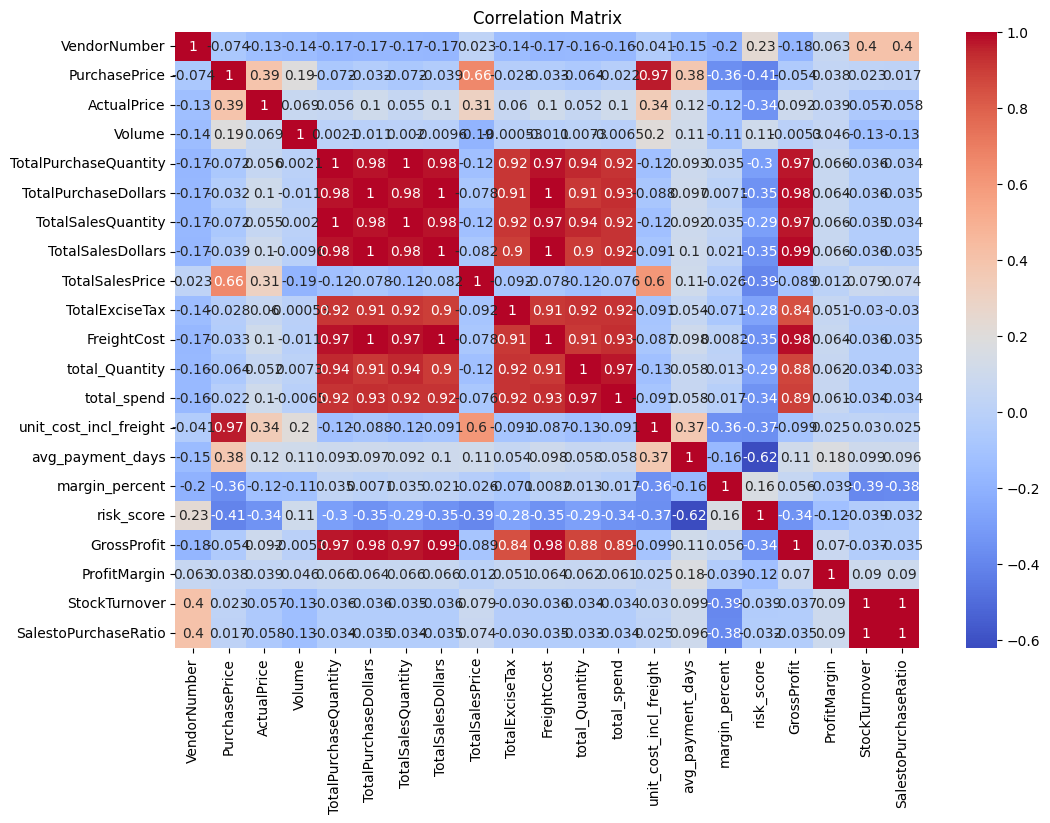

In [10]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

* Insight:

The correlation matrix shows strong positive relationships between purchase quantity, purchase dollars, sales quantity, and sales dollars. This indicates that higher purchasing volumes generally lead to higher sales and revenue generation.

* Vendor wise profite

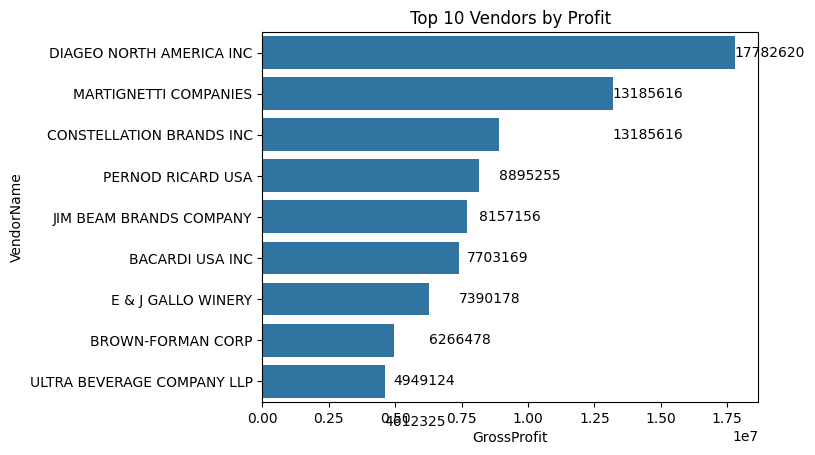

In [11]:
top10 = df.sort_values("GrossProfit", ascending=False).head(10)

ax = sns.barplot(data=top10, x="GrossProfit", y="VendorName")

# value label show
for i, v in enumerate(top10["GrossProfit"]):
    ax.text(v, i, f'{v:.0f}', va='center')

plt.title("Top 10 Vendors by Profit")
plt.show()

* Insight:

The profit distribution indicates that a small group of vendors contributes significantly to total profitability. DIAGEO NORTH AMERICA INC generates the highest profit, followed by MARTIGNETTI COMPANIES and CONSTELLATION BRANDS INC.

* Risk Analysis

Text(0.5, 1.0, 'Vendor Risk Distribution')

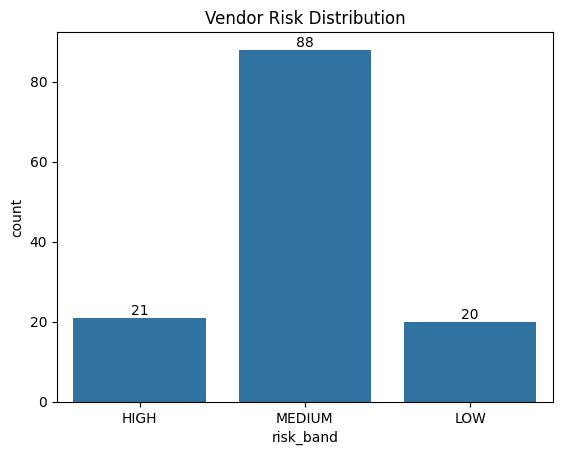

In [12]:
ax = sns.countplot(data=df, x="risk_band")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Vendor Risk Distribution")

* Insight:

Most vendors fall into the medium risk category, while relatively fewer vendors are classified as high or low risk. This suggests that the majority of suppliers carry moderate operational or financial risk.

* Sales vs Purchase Analysis

Text(0.5, 1.0, 'Sales vs Purchase')

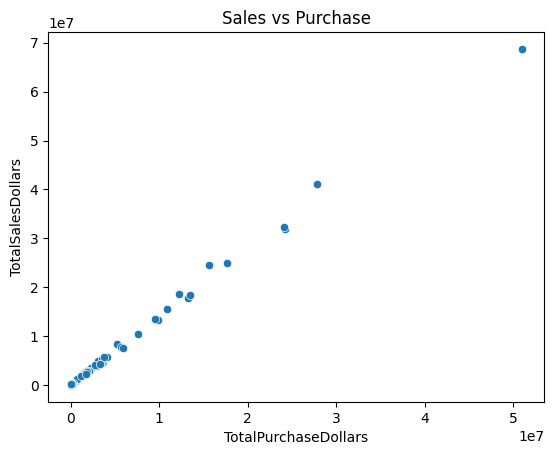

In [13]:
sns.scatterplot(
    data=df,
    x="TotalPurchaseDollars",
    y="TotalSalesDollars"
)

plt.title("Sales vs Purchase")

* Insight

The scatter plot shows a strong positive relationship between total purchase dollars and total sales dollars. Vendors with higher purchase investments generally generate higher sales revenue.

* Stock Turnover Distribution

Text(0.5, 1.0, 'Stock Turnover Distribution ')

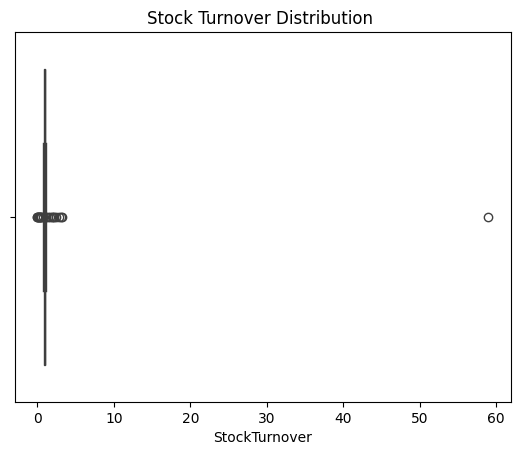

In [14]:
sns.boxplot(x = df['StockTurnover'])
plt.title("Stock Turnover Distribution ")

* Insight

Most vendors have relatively low stock turnover values, indicating that inventory movement is slow for many products. A few outliers show very high turnover, suggesting faster-selling items.

* which vendor product is more sell

In [15]:
top_vendors = (
    df.groupby("VendorName")["TotalSalesDollars"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Text(0, 0.5, 'Vendor Name')

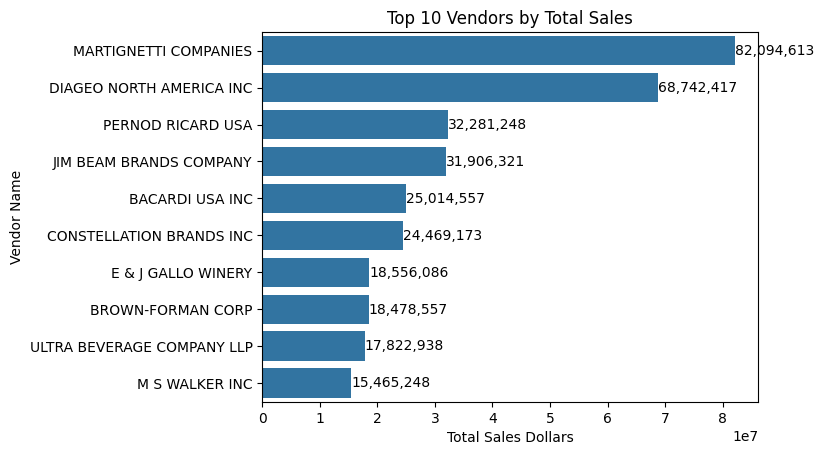

In [16]:
top_vendors_df = top_vendors.reset_index()


ax = sns.barplot(
    data=top_vendors_df,
    x="TotalSalesDollars",
    y="VendorName"
)

for i, v in enumerate(top_vendors_df["TotalSalesDollars"]):
    ax.text(v, i, f'{v:,.0f}', va='center')

plt.title("Top 10 Vendors by Total Sales")
plt.xlabel("Total Sales Dollars")
plt.ylabel("Vendor Name")

* Insight

Sales revenue is concentrated among a small number of vendors. MARTIGNETTI COMPANIES and DIAGEO NORTH AMERICA INC generate the highest sales, highlighting their importance as key revenue contributors.

* Capital Locked in Unsold Inventory by Vendor

In [17]:
df["UnsoldInventoryValue"] = df["TotalPurchaseDollars"] - df["TotalSalesDollars"]

unsold_inventory = (
    df.groupby("VendorName")["UnsoldInventoryValue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(unsold_inventory)

VendorName
ADAMBA IMPORTS INTL INC          9194.03
BLACK COVE BEVERAGES             8208.19
IRA GOLDMAN AND WILLIAMS, LLP    4365.30
HIGHLAND WINE MERCHANTS LLC      3966.64
UNCORKED                         1841.93
GILMANTON WINERY & VINEYARD      1555.44
LOYAL DOG WINERY                 1209.54
TAMWORTH DISTILLING              1015.32
APPOLO VINEYARDS LLC              782.78
STARK BREWING COMPANY             589.50
Name: UnsoldInventoryValue, dtype: float64


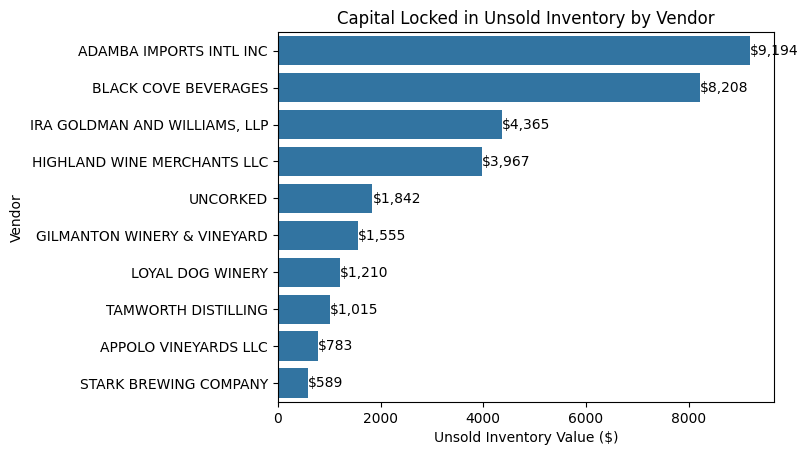

In [18]:
unsold_df = unsold_inventory.reset_index()

ax = sns.barplot(
    data=unsold_df,
    x="UnsoldInventoryValue",
    y="VendorName"
)

for i, v in enumerate(unsold_df["UnsoldInventoryValue"]):
    ax.text(v, i, f'${v:,.0f}', va='center')

plt.title("Capital Locked in Unsold Inventory by Vendor")
plt.xlabel("Unsold Inventory Value ($)")
plt.ylabel("Vendor")

plt.show()

* Insight

Certain vendors contribute significantly to unsold inventory value, meaning more capital is tied up in their products. This may indicate excess inventory or slow-moving stock that requires better inventory management.

* Which vendors contribute the most to total purchase doller

* Top 10 vendor as a supplier

In [19]:
top_purchase_vendors = (
    df.groupby("VendorName")["TotalPurchaseDollars"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Text(0, 0.5, 'Vendor Name')

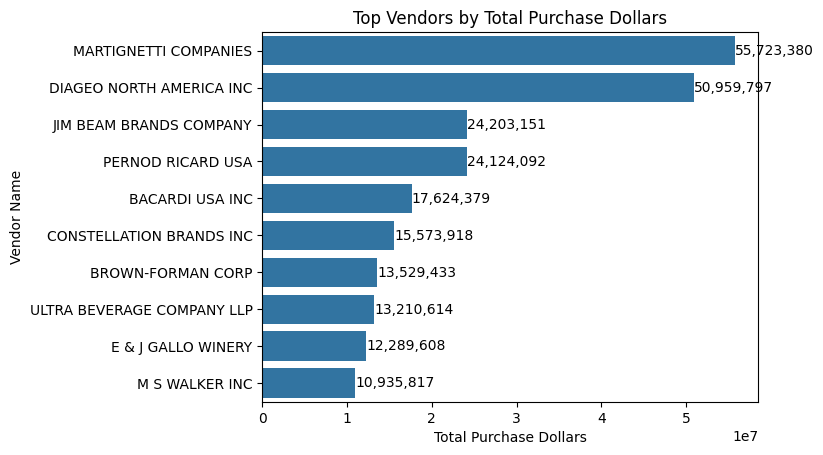

In [20]:
top_purchase_vendors_df = top_purchase_vendors.reset_index()

ax = sns.barplot(
    data=top_purchase_vendors_df,
    x="TotalPurchaseDollars",
    y="VendorName"
)

for i, v in enumerate(top_purchase_vendors_df["TotalPurchaseDollars"]):
    ax.text(v, i, f'{v:,.0f}', va='center')

plt.title("Top Vendors by Total Purchase Dollars")
plt.xlabel("Total Purchase Dollars")
plt.ylabel("Vendor Name")

* Insight

Procurement spending is concentrated among a few key vendors. MARTIGNETTI COMPANIES and DIAGEO NORTH AMERICA INC account for the highest purchase amounts, indicating strong dependence on these suppliers.

* Does Bulk Purchasing Reduce Unit Price?

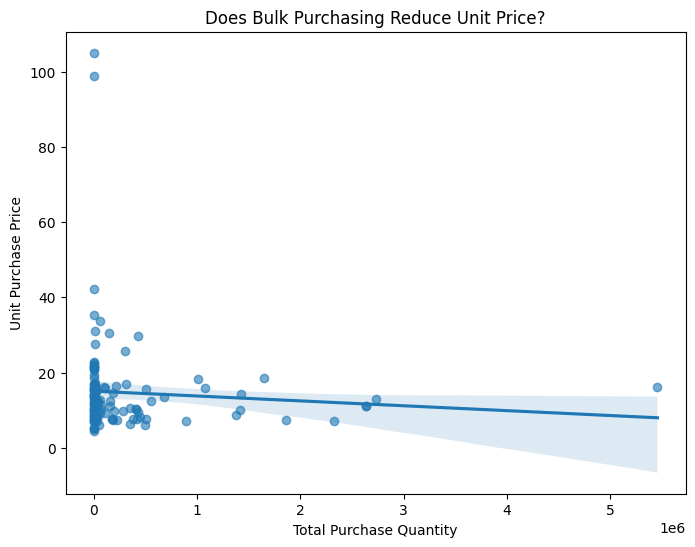

In [21]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="TotalPurchaseQuantity",
    y="PurchasePrice",
    scatter_kws={"alpha":0.6}
)

plt.title("Does Bulk Purchasing Reduce Unit Price?")
plt.xlabel("Total Purchase Quantity")
plt.ylabel("Unit Purchase Price")

plt.show()

In [22]:
df["quantity_bucket"] = pd.qcut(df["TotalPurchaseQuantity"], q=4)

price_analysis = df.groupby("quantity_bucket")["PurchasePrice"].mean()

print(price_analysis)

quantity_bucket
(0.999, 1847.0]          19.614221
(1847.0, 12798.0]        14.362266
(12798.0, 192642.0]      12.443372
(192642.0, 5459788.0]    12.187353
Name: PurchasePrice, dtype: float64


C:\Users\Asus\AppData\Local\Temp\ipykernel_3004\947407032.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_analysis = df.groupby("quantity_bucket")["PurchasePrice"].mean()


Text(0, 0.5, 'Average Unit Price')

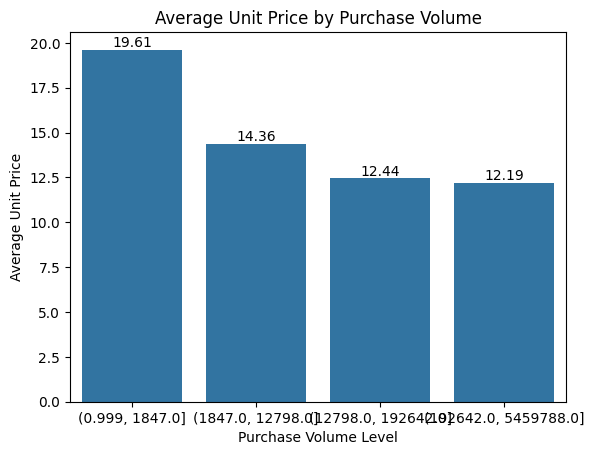

In [23]:
ax = sns.barplot(
    x=price_analysis.index.astype(str),
    y=price_analysis.values
)

# value labels on bars
for i, v in enumerate(price_analysis.values):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.title("Average Unit Price by Purchase Volume")
plt.xlabel("Purchase Volume Level")
plt.ylabel("Average Unit Price")

* Insight

The chart shows that average unit prices decrease as purchase volume increases, suggesting that bulk purchasing helps reduce unit costs and improves procurement efficiency.

* which vendor product sell slow

In [24]:
low_turnover_vendors = (
    df.sort_values("StockTurnover")
    .head(10)
)

print(low_turnover_vendors[["VendorName","StockTurnover"]])

                        VendorName  StockTurnover
24             LAUREATE IMPORTS CO       0.000000
112    AAPER ALCOHOL & CHEMICAL CO       0.000000
6                     TRUETT HURST       0.041667
84   IRA GOLDMAN AND WILLIAMS, LLP       0.128049
89     HIGHLAND WINE MERCHANTS LLC       0.220430
82                        UNCORKED       0.255144
5                 LOYAL DOG WINERY       0.308333
97            BLACK COVE BEVERAGES       0.340588
68     GILMANTON WINERY & VINEYARD       0.465116
60            APPOLO VINEYARDS LLC       0.469565


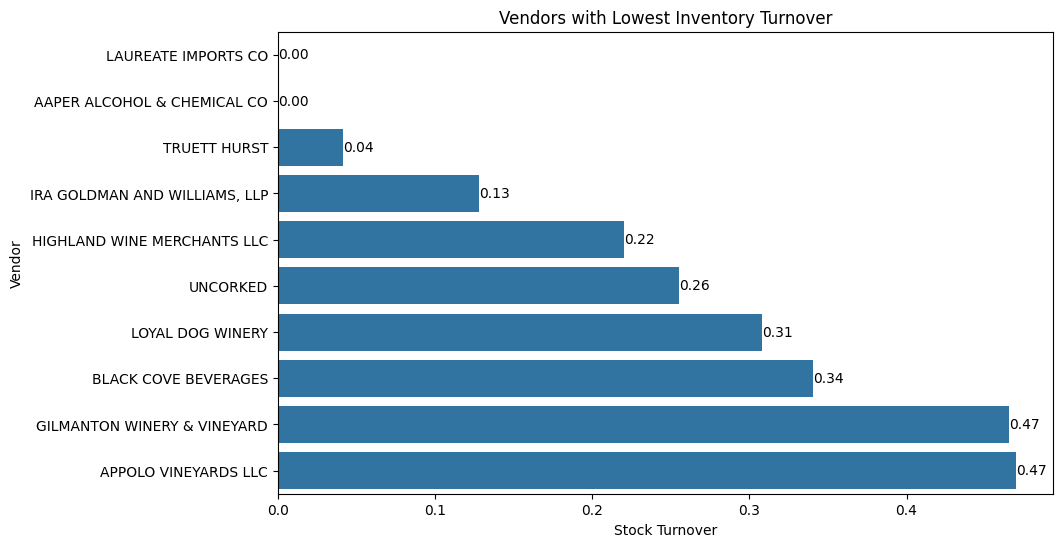

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

low_turnover = df.sort_values("StockTurnover").head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=low_turnover,
    x="StockTurnover",
    y="VendorName"
)

for i, v in enumerate(low_turnover["StockTurnover"]):
    ax.text(v, i, f'{v:.2f}', va='center')

plt.title("Vendors with Lowest Inventory Turnover")
plt.xlabel("Stock Turnover")
plt.ylabel("Vendor")

plt.show()

* Insight

Vendors with very low stock turnover indicate slow-moving inventory, suggesting potential overstock issues and inefficient inventory utilization for those products.

Top Vendors 95% CI: (28.23, 31.88), Mean: 30.05
Low Vendors 95% CI: (17.61, 41.84), Mean: 29.72


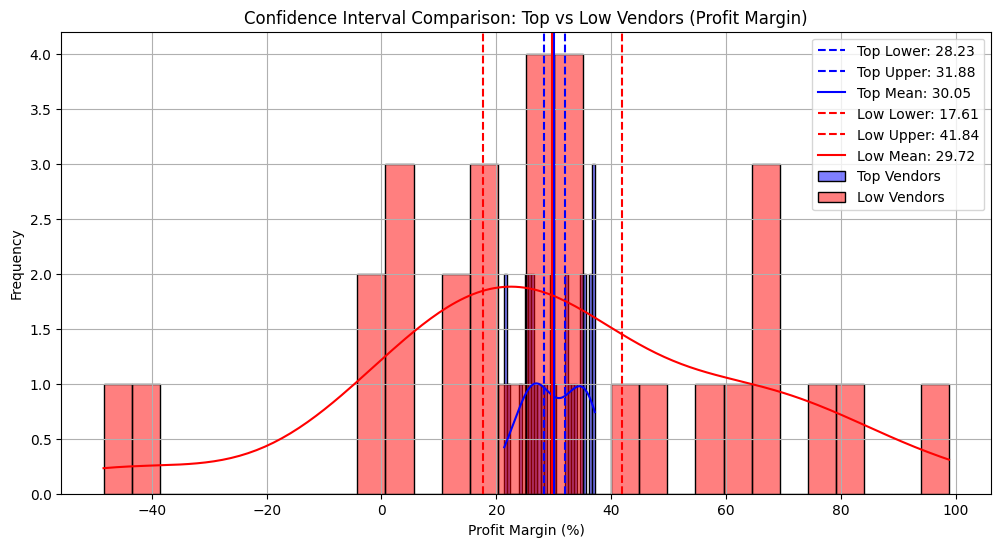

In [ ]:


# Clean ProfitMargin
df["ProfitMargin"] = df["ProfitMargin"].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["ProfitMargin"])

# Remove extreme outliers
df = df[(df["ProfitMargin"] >= -100) & (df["ProfitMargin"] <= 100)]

# Thresholds
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Group data
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Confidence interval function
def confidence_interval(data, confidence=0.95):
    data = np.array(data)
    data = data[~np.isnan(data)]
    data = data[np.isfinite(data)]
    
    if len(data) < 2:
        return np.nan, np.nan, np.nan
    
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    
    lower = mean_val - margin_of_error
    upper = mean_val + margin_of_error
    
    return mean_val, lower, upper

# Calculate CI
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

# Plot
plt.figure(figsize=(12,6))

sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

plt.title("Confidence Interval Comparison: Top vs Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

* Insight

This graph compares the profit margin distribution between top-performing vendors and low-performing vendors.
The top vendors have a stable profit margin with a mean around 30% and a narrow confidence interval.
In contrast, low vendors show a much wider confidence interval, indicating greater variability and less consistent profitability.

## Hypothesis

We compare the profit margin between **Top Vendors** and **Low Vendors**.

**Null Hypothesis (H₀):**  
There is no significant difference in profit margin between top vendors and low vendors.  
\[
H_0 : \mu_{top} = \mu_{low}
\]

**Alternative Hypothesis (H₁):**  
There is a significant difference in profit margin between top vendors and low vendors.  
\[
H_1 : \mu_{top} \neq \mu_{low}
\]